<a href="https://colab.research.google.com/github/sajivjose174/Project/blob/main/Jamboree_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Jamboree Education - Linear Regression**

##Problem Statement:
Analysis to help Jamboree in understanding what factors are important in graduate admissions and how these factors are interrelated among themselves. and also help predict one's chances of admission given the rest of the variables.

In [ ]:
#import data

!curl -o Jamboree_Admission.csv "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/839/original/Jamboree_Admission.csv"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 16176  100 16176    0     0   139k      0 --:--:-- --:--:-- --:--:--  141k


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_Jamboree=pd.read_csv('Jamboree_Admission.csv')

In [ ]:
df_Jamboree

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
495,496,332,108,5,4.5,4.0,9.02,1,0.87
496,497,337,117,5,5.0,5.0,9.87,1,0.96
497,498,330,120,5,4.5,5.0,9.56,1,0.93
498,499,312,103,4,4.0,5.0,8.43,0,0.73


In [ ]:
#Checking data types of all the attributes
df_Jamboree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [ ]:
#Shape of Data
df_Jamboree.shape

(500, 9)

In [ ]:
#null values check:

df_Jamboree.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [ ]:
#duplicates check:

df_Jamboree.duplicated().sum()

np.int64(0)

In [ ]:
#statistical summary:

df_Jamboree.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


##Exploratory Data Analysis

In [ ]:
# Unique Values
for i in df_Jamboree.columns:
  print (f"{i}:", df_Jamboree[i].nunique())

Serial No.: 500
GRE Score: 49
TOEFL Score: 29
University Rating: 5
SOP: 9
LOR : 9
CGPA: 184
Research: 2
Chance of Admit : 61


In [ ]:
# Value counts
for i in df_Jamboree.columns:
  print (f"{i}:", df_Jamboree[i].value_counts())

GRE Score: GRE Score
312    24
324    23
316    18
322    17
327    17
321    17
311    16
320    16
314    16
325    15
317    15
308    13
323    13
315    13
300    12
319    12
313    12
326    12
304    12
318    12
305    11
310    11
301    11
307    10
329    10
299    10
298    10
331     9
328     9
309     9
340     9
330     8
334     8
332     8
302     7
306     7
297     6
296     5
303     5
336     5
295     5
333     4
338     4
335     4
339     3
337     2
294     2
290     2
293     1
Name: count, dtype: int64
TOEFL Score: TOEFL Score
110    44
105    37
104    29
106    28
107    28
112    28
103    25
100    24
102    24
99     23
111    20
101    20
108    19
109    19
113    19
114    18
116    16
115    11
118    10
119    10
98     10
120     9
117     8
97      7
96      6
95      3
93      2
94      2
92      1
Name: count, dtype: int64
University Rating: University Rating
3    162
2    126
4    105
5     73
1     34
Name: count, dtype: int64
SOP: SOP
4.0  

In [ ]:
#outlier checks:

# Numeric columns (excluding Serial No.)
num_cols = df_Jamboree.select_dtypes(include=[np.number]).columns.tolist()
if "Serial No." in num_cols:
    num_cols.remove("Serial No.")

# Function to count outliers
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

# Count outliers per numeric column
outlier_counts = {col: count_outliers(df_Jamboree[col]) for col in num_cols}
print(outlier_counts)


{'GRE Score': np.int64(0), 'TOEFL Score': np.int64(0), 'University Rating': np.int64(0), 'SOP': np.int64(0), 'LOR ': np.int64(1), 'CGPA': np.int64(0), 'Research': np.int64(0), 'Chance of Admit ': np.int64(2)}


In [ ]:
#dropping the unique feature: (for feature modelling)

df_Jamboree.drop('Serial No.',axis=1,inplace=True)

##Graphical Analysis:

In [ ]:
df_Jamboree.head(5)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


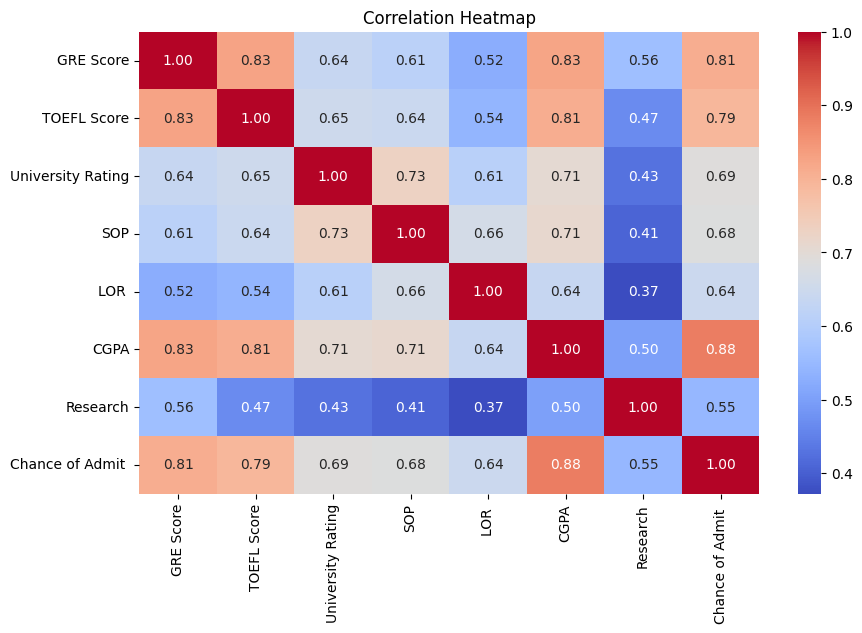

In [ ]:
#Bivariate Analysis (Heatmaps)

plt.figure(figsize=(10,6))
sns.heatmap(df_Jamboree.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

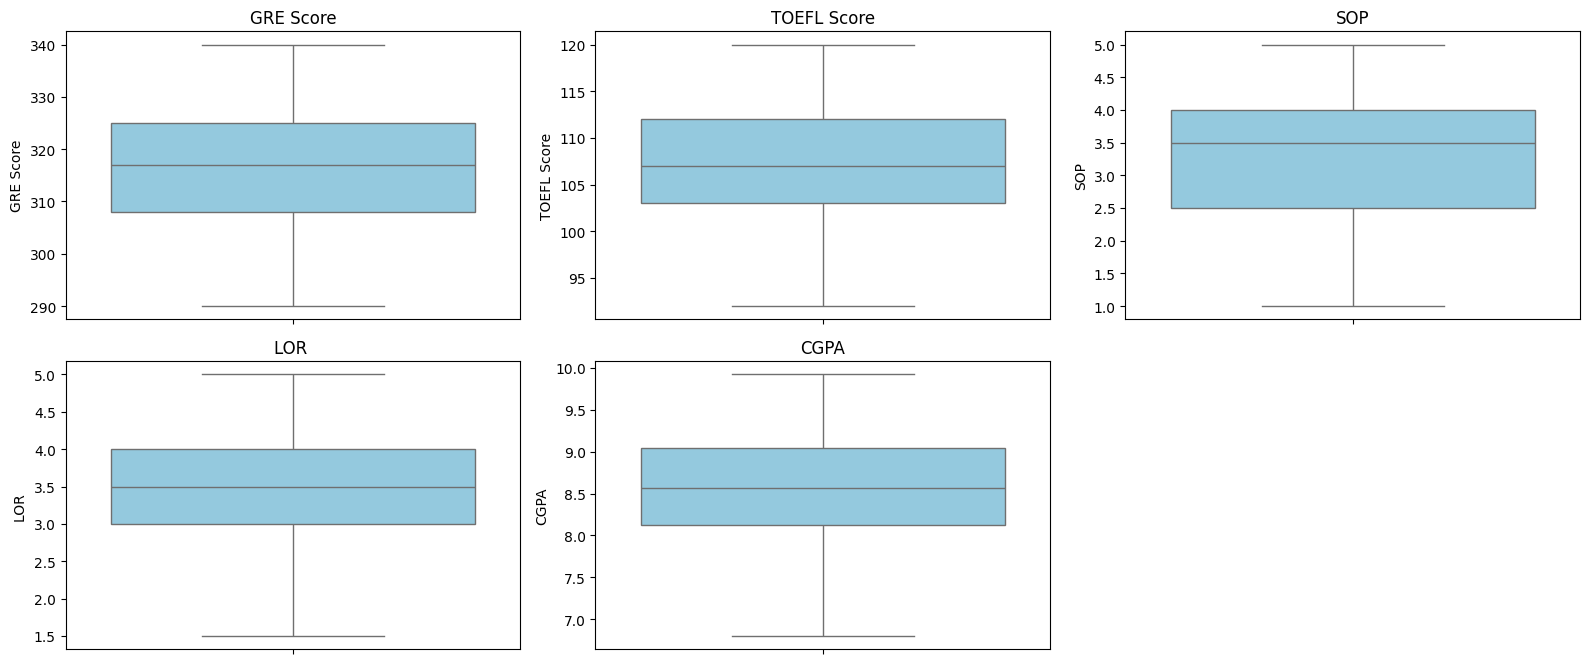

In [ ]:
#univariate analysis:barplots/countplots
continuous_cols = ['GRE Score', 'TOEFL Score', 'SOP', 'LOR ', 'CGPA']
plt.figure(figsize=(16, 10))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3, 3, i)  # 3 rows, 3 cols grid
    sns.boxplot(y=df_Jamboree[col], color='skyblue')
    plt.title(col, fontsize=12)
    plt.tight_layout()
plt.show()

/tmp/ipython-input-1521211067.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_Jamboree, palette='Set2')
/tmp/ipython-input-1521211067.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_Jamboree, palette='Set2')


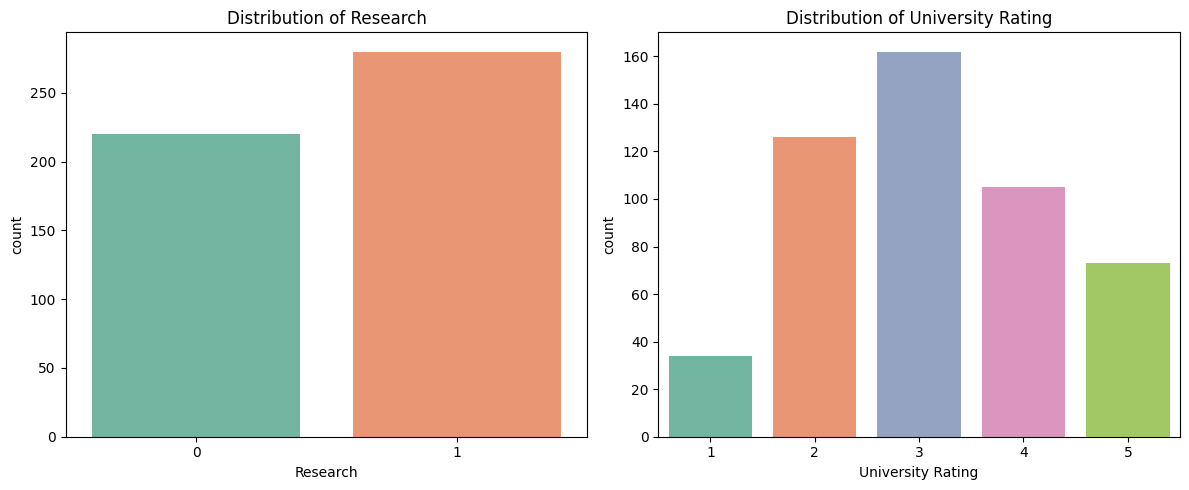

In [ ]:
##univariate analysis: barplots/countplots

categorical_cols = ['Research', 'University Rating']

plt.figure(figsize=(12,5))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, len(categorical_cols), i)
    sns.countplot(x=col, data=df_Jamboree, palette='Set2')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

/tmp/ipython-input-3707957816.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Chance of Admit ', data=df_Jamboree, palette='Set2')
/tmp/ipython-input-3707957816.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Chance of Admit ', data=df_Jamboree, palette='Set2')


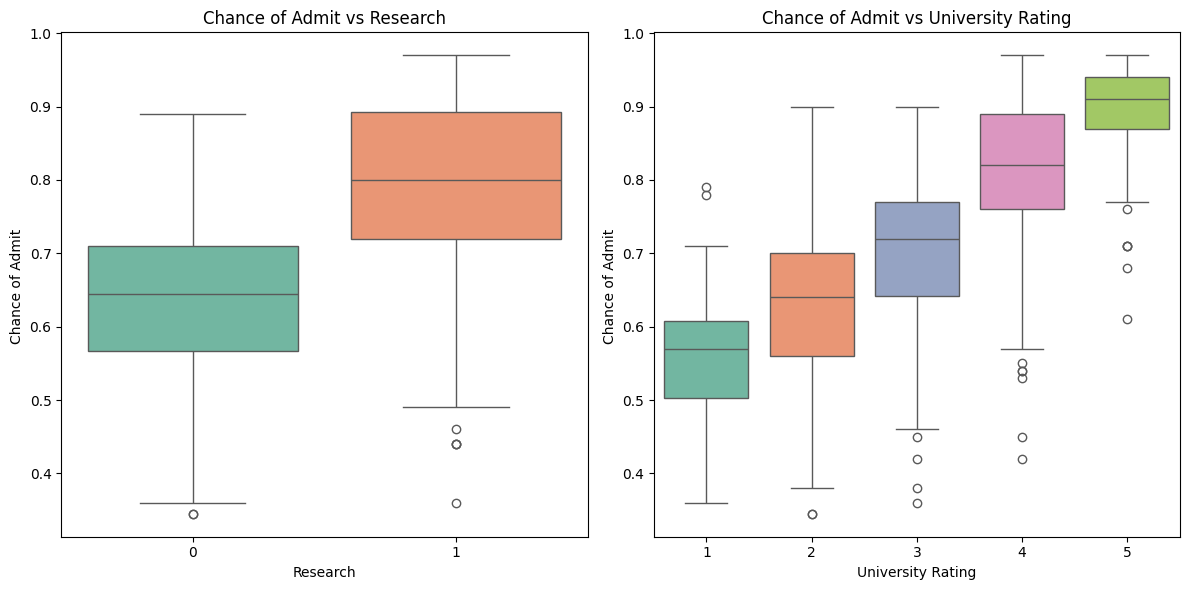

In [ ]:
#Colured hued boxplots:

categorical_cols = ['Research', 'University Rating']

plt.figure(figsize=(12,6))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, len(categorical_cols), i)
    sns.boxplot(x=col, y='Chance of Admit ', data=df_Jamboree, palette='Set2')
    plt.title(f'Chance of Admit vs {col}')

plt.tight_layout()
plt.show()

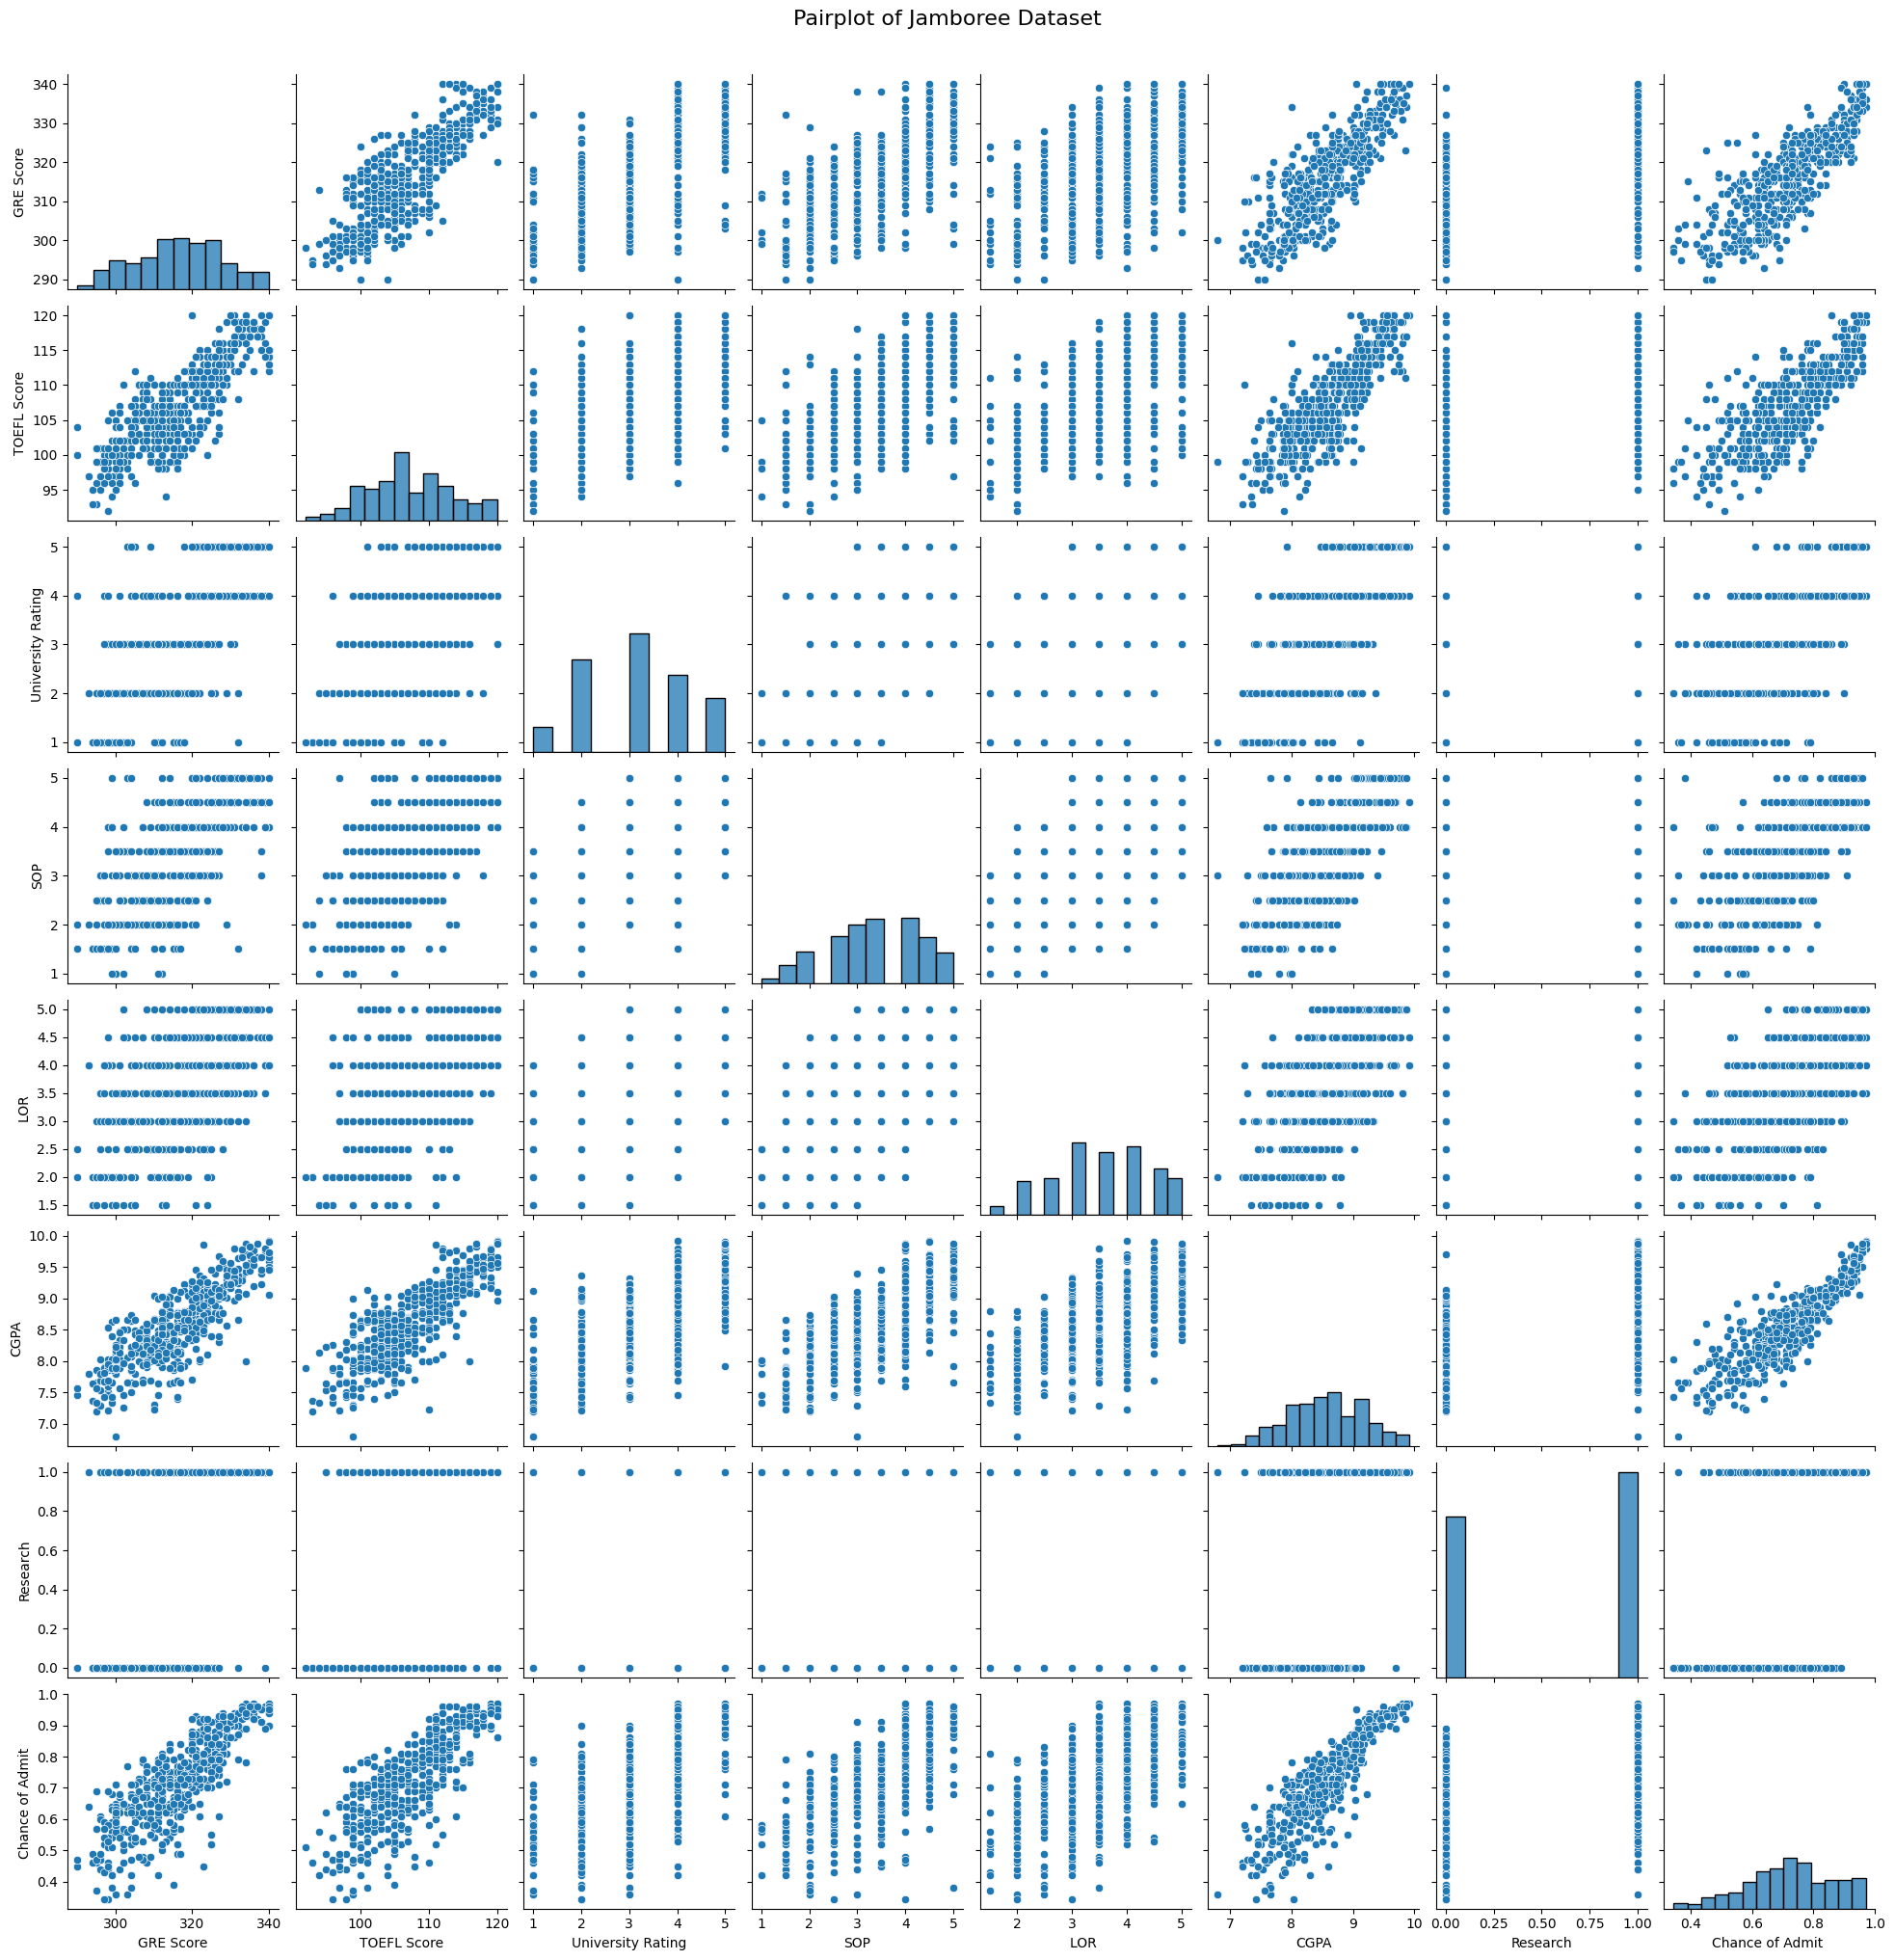

In [ ]:
#Pairplot: To understand the underlying data:

sns.pairplot(df_Jamboree)
plt.suptitle("Pairplot of Jamboree Dataset", fontsize=16, y=1.02)
plt.show()

#Model building:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [ ]:
y=df_Jamboree['Chance of Admit ']
X=df_Jamboree.drop(columns='Chance of Admit ',axis=1)

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_cap=lr.predict(X_test)
y_cap

array([0.91452462, 0.79525676, 0.57265977, 0.70739313, 0.81586963,
       0.86208051, 0.47468389, 0.64854096, 0.82378223, 0.80733346,
       0.72196609, 0.72593749, 0.65635459, 0.93670906, 0.82415436,
       0.50987005, 0.83933824, 0.59739928, 0.53344476, 0.57156851,
       0.66546236, 0.55316682, 0.72245202, 0.79503379, 0.78022873,
       0.60256938, 0.94832375, 0.84747348, 0.62779393, 0.74352106,
       0.55548985, 0.73005276, 0.54483912, 0.86113323, 0.65715036,
       0.73716573, 0.55432439, 0.95714984, 0.64372297, 0.7106652 ,
       0.97034285, 0.57507683, 0.67077495, 0.85829903, 0.94105145,
       0.57809054, 0.95832614, 0.83900045, 0.79592044, 0.92569042,
       0.88809249, 0.56377281, 0.7037483 , 0.52671199, 0.95355806,
       0.59751251, 0.95593783, 0.73923302, 0.66266105, 0.50147406,
       0.62960518, 0.68031443, 0.59900784, 0.59224925, 0.44097634,
       0.58877606, 0.86675666, 0.89775543, 0.65829467, 0.7066294 ,
       0.6177677 , 0.78586304, 0.69154637, 0.5627518 , 0.55430

In [ ]:
print("R^2 for train:",lr.score(X_train,y_train))
print('R^2 for test:',lr.score(X_test,y_test))

R^2 for train: 0.8213379717854047
R^2 for test: 0.8187280986509646


In [ ]:
#Display model coefficients with column names:

coefficients=pd.DataFrame({"Features":X.columns, "Coeffecints":lr.coef_})
coefficients

,Features,Coeffecints
0,GRE Score,0.026640
1,TOEFL Score,0.018191
2,University Rating,0.002932
3,SOP,0.001856
4,LOR,0.015838
5,CGPA,0.067576
6,Research,0.011935




*   CGPA still has the largest impact and the strongest predictor of Chance of Admit.
*   GRE and TOEFL moderate impact.

*   University Rating, SOP, LOR, Research small but positive contributions






In [ ]:
print("Intercept:",lr.intercept_)

Intercept: 0.7242000000000001


In [ ]:
#trying out lasso adn ridge regressions:

from sklearn.linear_model import Lasso, Ridge

In [ ]:
#taking alpha=0.001

In [ ]:
lasso_model = Lasso(alpha=0.001)
ridge_model = Ridge(alpha=0.001)

In [ ]:
lasso_model.fit(X_train,y_train)

Lasso(alpha=0.001)

In [ ]:
ridge_model.fit(X_train,y_train)

Ridge(alpha=0.001)

In [ ]:
lasso_model.predict(X_test)

array([0.91343332, 0.79419259, 0.57416553, 0.70835088, 0.81542498,
       0.8608332 , 0.47707865, 0.64958295, 0.82306012, 0.80603009,
       0.72279382, 0.72679241, 0.65631233, 0.93483   , 0.82386465,
       0.51227624, 0.83800403, 0.59787908, 0.53565322, 0.57126719,
       0.66483248, 0.55405981, 0.72177518, 0.79414967, 0.77979436,
       0.60324332, 0.94601533, 0.84615983, 0.62907814, 0.74241907,
       0.5568684 , 0.73120558, 0.54689954, 0.85965853, 0.65673887,
       0.73667306, 0.55652726, 0.95485291, 0.64306476, 0.71046228,
       0.96845124, 0.57549546, 0.6708969 , 0.85667326, 0.93961787,
       0.58017752, 0.95653144, 0.83754731, 0.79465678, 0.92348036,
       0.88615984, 0.56496122, 0.70343739, 0.52792292, 0.95131135,
       0.59848   , 0.954886  , 0.73993751, 0.66324317, 0.50244893,
       0.63051214, 0.68009877, 0.600853  , 0.59262113, 0.44365324,
       0.58927284, 0.86518235, 0.89578923, 0.65937608, 0.70789569,
       0.61781223, 0.78518851, 0.69311742, 0.56394321, 0.55665

In [ ]:
ridge_model.predict(X_test)

array([0.91452427, 0.79525658, 0.57266024, 0.70739291, 0.81586939,
       0.86208038, 0.47468388, 0.64854078, 0.8237817 , 0.80733339,
       0.72196614, 0.72593733, 0.6563551 , 0.93670903, 0.82415388,
       0.5098699 , 0.83933838, 0.59739917, 0.53344467, 0.57156884,
       0.66546245, 0.55316718, 0.72245196, 0.79503379, 0.78022874,
       0.60256934, 0.94832363, 0.84747348, 0.62779401, 0.74352121,
       0.55549017, 0.73005253, 0.54483937, 0.86113301, 0.65715078,
       0.73716575, 0.5543241 , 0.9571497 , 0.6437232 , 0.71066523,
       0.9703425 , 0.57507694, 0.67077475, 0.85829905, 0.94105116,
       0.57809032, 0.95832586, 0.83900046, 0.79592058, 0.92569033,
       0.88809226, 0.56377296, 0.70374847, 0.5267123 , 0.95355799,
       0.59751321, 0.95593728, 0.73923295, 0.66266085, 0.50147436,
       0.62960477, 0.68031423, 0.59900763, 0.59225005, 0.44097642,
       0.5887768 , 0.86675651, 0.89775535, 0.65829449, 0.70662908,
       0.61776773, 0.78586304, 0.69154597, 0.56275227, 0.55430

In [ ]:
print("R^2 for lasso:",lasso_model.score(X_test,y_test))
print('R^2 for ridge:',ridge_model.score(X_test,y_test))

R^2 for lasso: 0.8190425132245003
R^2 for ridge: 0.8187280423671055


In [ ]:
#checing multiple alphas:

alphas = [0.001, 0.01, 0.1, 1, 10]
for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42).fit(X_train, y_train)
    ridge = Ridge(alpha=alpha, random_state=42).fit(X_train, y_train)

    print(f"Alpha = {alpha}")
    print(f"  Lasso R² (test): {lasso.score(X_test, y_test):.4f}")
    print(f"  Ridge R² (test): {ridge.score(X_test, y_test):.4f}\n")

Alpha = 0.001
  Lasso R² (test): 0.8190
  Ridge R² (test): 0.8187

Alpha = 0.01
  Lasso R² (test): 0.8137
  Ridge R² (test): 0.8187

Alpha = 0.1
  Lasso R² (test): 0.2666
  Ridge R² (test): 0.8187

Alpha = 1
  Lasso R² (test): -0.0073
  Ridge R² (test): 0.8187

Alpha = 10
  Lasso R² (test): -0.0073
  Ridge R² (test): 0.8181



In [ ]:
##All features are important.
##Regularization is not strictly needed.

#Testing the assumptions of the linear regression model

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
x_const=sm.add_constant(X)
x_const

,const,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,1.0,337,118,4,4.5,4.5,9.65,1
1,1.0,324,107,4,4.0,4.5,8.87,1
2,1.0,316,104,3,3.0,3.5,8.00,1
3,1.0,322,110,3,3.5,2.5,8.67,1
4,1.0,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...,...
495,1.0,332,108,5,4.5,4.0,9.02,1
496,1.0,337,117,5,5.0,5.0,9.87,1
497,1.0,330,120,5,4.5,5.0,9.56,1
498,1.0,312,103,4,4.0,5.0,8.43,0


In [ ]:
vif=pd.DataFrame()

vif['Features']=x_const.columns

vif['VIF']=[variance_inflation_factor(x_const.values,i) for i in range(x_const.shape[1])]


In [ ]:
x_const.values

array([[  1.  , 337.  , 118.  , ...,   4.5 ,   9.65,   1.  ],
       [  1.  , 324.  , 107.  , ...,   4.5 ,   8.87,   1.  ],
       [  1.  , 316.  , 104.  , ...,   3.5 ,   8.  ,   1.  ],
       ...,
       [  1.  , 330.  , 120.  , ...,   5.  ,   9.56,   1.  ],
       [  1.  , 312.  , 103.  , ...,   5.  ,   8.43,   0.  ],
       [  1.  , 327.  , 113.  , ...,   4.5 ,   9.04,   0.  ]])

In [ ]:
x_const.shape[1]

8

In [ ]:
#Multicollinearity check by VIF score

vif

,Features,VIF
0,const,1511.493918
1,GRE Score,4.463733
2,TOEFL Score,3.904258
3,University Rating,2.621300
4,SOP,2.833239
5,LOR,2.029224
6,CGPA,4.777833
7,Research,1.493982


In [ ]:
#None of the predictors show dangerous multicollinearity. Safe to keep all predictors.

In [ ]:
##Normality of residuals
y_cap_resi=lr.predict(X_test)

error=(y_test-y_cap_resi).to_numpy()

<Axes: ylabel='Count'>

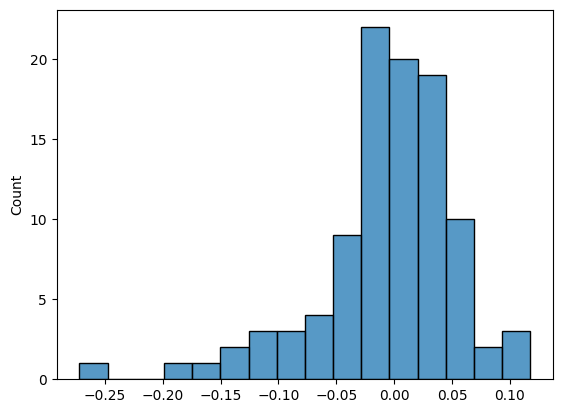

In [ ]:
sns.histplot(error)

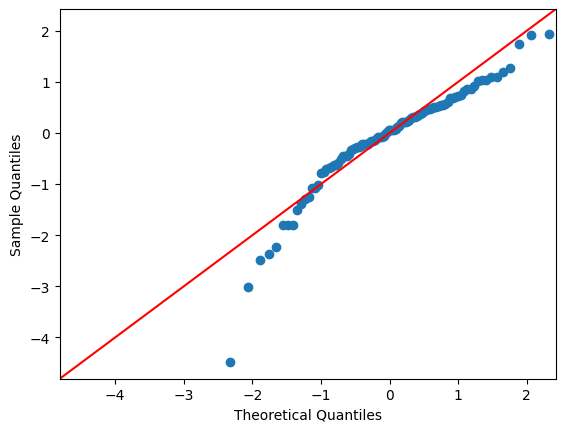

In [ ]:
error1=error/error.std()
sm.qqplot(error1, line ='45')
plt.show()

In [ ]:
from scipy.stats import shapiro
stat, p = shapiro(error)
print("Shapiro-Wilk test p-value:", p)
if p > 0.05:
    print("Residuals are approximately normal")
else:
    print("Residuals are not normal")

Shapiro-Wilk test p-value: 1.1787461029478304e-05
Residuals are not normal


In [ ]:
##Residuals are not normal



*   The mean of residuals is nearly zero
*   Normality test (bell shaped curve)

*   QQ-plot to check.
*   Shapior wilk to confirm









In [ ]:
#However, residuals are small, roughly symmetric around 0, and linear regression predictions are reliable.
#Normality assumption violation is unlikely to affect predictive performance.


In [ ]:
error.mean()
#The mean of residuals is nearly zero

np.float64(-0.005571240709787845)

In [ ]:
##hetereoskedacity

<Axes: >

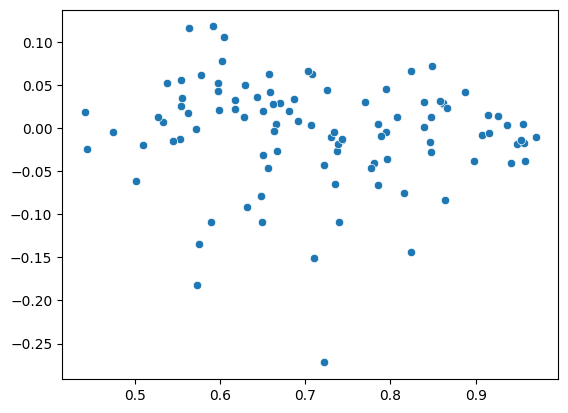

In [ ]:
sns.scatterplot(x=y_cap_resi, y=error)

In [ ]:
# Performing the Goldfeld-Quandt test to check for Homoscedasticity
from statsmodels.stats.diagnostic import het_goldfeldquandt

test=het_goldfeldquandt(y_train, X_train)
print("p-value:", test[1])

p-value: 0.49217055385360653




*   model satisfies the homoscedasticity assumption.
*   Fail to reject the null hypothesis there is no evidence of heteroscedasticity.

*    significance =0.05





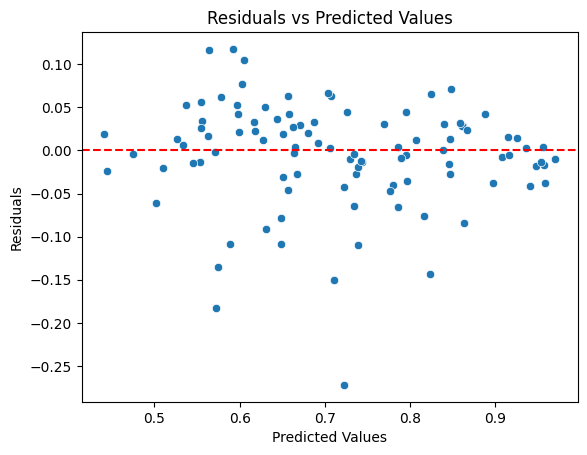

In [ ]:
#Linearity of variables

sns.scatterplot(x=y_cap_resi, y=error)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

In [ ]:
#No patterns in the plot.



*   All VIFs < 5, no multicollinearity concerns.

*   Residuals vs predicted values scatter plot shows no clear pattern.

*   Shapiro-Wilk test p-value < 0.05,residuals slightly deviate from normality
*   Histogram shows residuals roughly symmetric around 0.


*   Mean of residuals is almost close to 0.


*   Goldfeld-Quandt test p-value=0.49, shows no heteroscedasticity



#Model performance evaluation

In [ ]:
#MAE

from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test, y_cap_resi)
print("MAE:", mae)

MAE: 0.042796800056570154


In [ ]:
#RMSE
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_cap_resi))
print("RMSE:", rmse)

RMSE: 0.06088522302322439


In [ ]:
#R2
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_cap_resi)
print("R2:", r2)


R2: 0.8187280986509646


In [ ]:
#Adj R2

n=X_test.shape[0]
p=X_test.shape[1]

adj_r2=1-(1-r2)*(n-1)/(n-p-1)
print("Adjusted R2:", adj_r2)

Adjusted R2: 0.8049356713744076


In [ ]:
##Train and test performances:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

# Train metrics
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = 1 - (1 - r2_train)*(X_train.shape[0]-1)/(X_train.shape[0]-X_train.shape[1]-1)
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))


# Test metrics
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = 1 - (1 - r2_test)*(X_test.shape[0]-1)/(X_test.shape[0]-X_test.shape[1]-1)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))


print("Train Performance:")
print(f"R²: {r2_train:.4f}, Adjusted R²: {adj_r2_train:.4f}, MAE: {mae_train:.4f}, RMSE: {rmse_train:.4f}\n")
print("Test Performance:")
print(f"R²: {r2_test:.4f}, Adjusted R²: {adj_r2_test:.4f}, MAE: {mae_test:.4f}, RMSE: {rmse_test:.4f}")

Train Performance:
R²: 0.8213, Adjusted R²: 0.8181, MAE: 0.0425, RMSE: 0.0593

Test Performance:
R²: 0.8187, Adjusted R²: 0.8049, MAE: 0.0428, RMSE: 0.0609


##Actionable Insights:




*   No null and No Duplicates observed.

*   The unique feature was dropped (Serial No.) as it is not useful for the model.

*   Outliers are not present during the univariate analysis, but on further investigation for mulitvarite analysis confirms group-based outliers. Since model is affected by global outliers (not present). The data set appears to be clean.
*   Distribution of Research shows imbalance.


*   Heat maps confirm strong relationship between GRE score and Chance of admit,
Toelf Score and Chance of admit,  CGPA and Chance of admit, while the rest had a moderate realtionship w.r.t Chance of admit.

*   CGPA still has the largest impact and the strongest predictor of Chance of Admit.
*   GRE and TOEFL moderate impact.

*   University Rating, SOP, LOR, Research small but positive contributions.





*   The features given are all important except the unique feature which was dropped early, as vif is less than 5, so no multi-colinearltu concerns.

*   Shapiro Wilk Test and QQ plot confirms slight deviation from normality. While Shapiro Wilk Test can be more strict in general.Histogram shows residuals roughly symmetric around 0.
*   Mean of residuals is almost close to 0.

*   Goldfeld-Quandt test p-value=0.49, confirms no heteroscedasticity.
*   


*   MAE = 0.043, my predicted model is off by 4.3%

*   RMSE = 0.061, A few predictions are further off.

*   RSME is greater than MAE. Since gap isnt huge, it is large errors and the chances of outliers being present is eliminated.

*   R2= 0.818, Model explains 81% variations in admission chances.
*   Adjusted R2=0.804, the model explains 80.5% vartions in admission chances.



















**Adjusted R2 slightly lower  than R2, as it penalizes extra features which are of not much importance.**



**Overall shows a strong fit, which confirms that the linear regression model is reliable.**



**Train and test performance are strong and similar,indicating the model fits well and generalizes reliably.**






**No immediate improvement is necessary for prediction.**



##Recommendations :



*   Try to retain the same features as the model is performing well, while showing the importance of the current features.
*   One could add Temporal Data (admission trend over the years), for improving the model's performance.


*   Demographic & Background Data could uncover hidden trends/patterns.
*   Extracurricular & Achievement Data as this could also enhance the model,
while at the same time looking if it contributed to muli-colinearity.



